In [2]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

run_number =51
# --- Parametri modificabili ---
X_TARGET = 5.0
Y_TARGET = 5.0

# Molteplicità per ogni detector — cambia solo questi!
MULT_DET0 = 1   # minimo hit detector 0
MULT_DET1 = 1   # minimo hit detector 1
MULT_DET2 = 0   # detector 2: whatever (0 = nessun vincolo)

# ------------------------------

branch_list = [
    'Detector', 'Feb', 'Channel', 'Cell0TimeStamp', 'TimeInstant',
    'TOTValue', 'PeakValue', 'Baseline', 'Amplitude', 'Waveform',
    'ArraySize', 'xCoord', 'yCoord', 'Multiplicity',
    'Davide', 'Golia', '7PAD', 'MCP'
]

branch_2d = [
    'Detector', 'Feb', 'Channel', 'Cell0TimeStamp', 'TimeInstant',
    'TOTValue', 'PeakValue', 'Baseline', 'Amplitude',
    'xCoord', 'yCoord'
]

branch_1d = ['ArraySize', 'Davide', 'Golia', '7PAD', 'MCP']

chunks = []

with uproot.open(f"~/Scrivania/sampic_run{run_number}_merged.root") as file:
    tree = file["picoTree"]
    n_tot = tree.num_entries

    for i, chunk in enumerate(tree.iterate(branch_list, library="ak", step_size=500)):
        n_chunk = len(chunk)

        array_size = ak.to_numpy(chunk['ArraySize'])     # (n_chunk,)
        mult       = ak.to_numpy(chunk['Multiplicity'])  # (n_chunk, 140)

        # xCoord e yCoord sono uguali per tutte le hit dell'evento, prendi la prima
        xcoord = ak.to_numpy(chunk['xCoord'])[:, 0]
        ycoord = ak.to_numpy(chunk['yCoord'])[:, 0]

        # --- Filtro evento ---
        '''mask_evento = (
            (((xcoord == X_TARGET) & (ycoord == Y_TARGET))|((xcoord == 0.5) & (ycoord==1)) &
            (mult[:, 0] == MULT_DET0) &
            (mult[:, 1] == MULT_DET1) &
            (mult[:, 2] >= MULT_DET2)   # se MULT_DET2=0 è sempre True
            )|(True)
        )'''

        #mask provvisoria
        mask_evento = ((xcoord == 9) & (ycoord == 5))
        #mask_evento= np.ones_like(xcoord, dtype=bool)  # seleziona tutti gli eventi
        if mask_evento.sum() == 0:
            continue

        n_sel = mask_evento.sum()
        array_size_filt = array_size[mask_evento]
        mult_filt       = mult[mask_evento]

        # --- Branch 2D ---
        arr_2d = {k: ak.to_numpy(chunk[k])[mask_evento] for k in branch_2d}
        rows_2d = {k: [] for k in arr_2d}
        for evt in range(n_sel):
            n_hit = array_size_filt[evt]
            for k in arr_2d:
                rows_2d[k].append(arr_2d[k][evt, :n_hit])
        df_2d = pd.DataFrame({k: np.concatenate(rows_2d[k]) for k in arr_2d})

        # --- Waveform ---
        waveform_raw = ak.to_numpy(chunk['Waveform'])[mask_evento]
        waveforms = []
        for evt in range(n_sel):
            n_hit = array_size_filt[evt]
            for hit in range(n_hit):
                waveforms.append(waveform_raw[evt, hit, :])
        df_2d['Waveform'] = waveforms

        # --- Branch 1D ---
        arr_1d = {k: ak.to_numpy(chunk[k])[mask_evento] for k in branch_1d}
        df_1d = pd.DataFrame({k: np.repeat(arr_1d[k], array_size_filt) for k in branch_1d})

        # --- Multiplicity come colonne separate ---
        df_mult = pd.DataFrame({
            'Mult_det1': np.repeat(mult_filt[:, 0], array_size_filt),
            'Mult_det2': np.repeat(mult_filt[:, 1], array_size_filt),
            'Mult_det3': np.repeat(mult_filt[:, 2], array_size_filt),
        })

        # --- Indice evento originale ---
        idx_originali = np.where(mask_evento)[0] + i * 5_000
        event_idx = np.repeat(idx_originali, array_size_filt)

        df_chunk = pd.concat([
            pd.Series(event_idx, name='event_idx'),
            df_2d.reset_index(drop=True),
            df_1d.reset_index(drop=True),
            df_mult.reset_index(drop=True)
        ], axis=1)

        chunks.append(df_chunk)
        print(f"Chunk {i+1} — eventi selezionati: {n_sel} — hit totali: {len(df_chunk)}")

df = pd.concat(chunks, ignore_index=True)
print(f"\n✅ DataFrame finale: {df.shape}")
print(df.head(50))

Chunk 3 — eventi selezionati: 1 — hit totali: 1
Chunk 12 — eventi selezionati: 1 — hit totali: 1
Chunk 25 — eventi selezionati: 1 — hit totali: 1
Chunk 82 — eventi selezionati: 1 — hit totali: 1
Chunk 86 — eventi selezionati: 120 — hit totali: 120
Chunk 87 — eventi selezionati: 359 — hit totali: 359
Chunk 88 — eventi selezionati: 404 — hit totali: 404
Chunk 89 — eventi selezionati: 404 — hit totali: 404
Chunk 90 — eventi selezionati: 369 — hit totali: 369
Chunk 91 — eventi selezionati: 412 — hit totali: 412
Chunk 92 — eventi selezionati: 446 — hit totali: 446
Chunk 93 — eventi selezionati: 391 — hit totali: 391
Chunk 94 — eventi selezionati: 446 — hit totali: 446
Chunk 95 — eventi selezionati: 453 — hit totali: 453
Chunk 96 — eventi selezionati: 450 — hit totali: 450
Chunk 97 — eventi selezionati: 446 — hit totali: 446
Chunk 98 — eventi selezionati: 461 — hit totali: 461
Chunk 99 — eventi selezionati: 465 — hit totali: 465
Chunk 100 — eventi selezionati: 445 — hit totali: 445
Chunk 101

In [3]:
df['Waveform'] = df['Waveform'].apply(lambda wf: np.delete(wf, 63)) # sample corrotto, lo elimino


   event_idx  Channel  Detector  integrale  ampiezza  rise_time  fwhm
0      10199       32       2.0   0.007746 -0.024350        4.0   6.0
1      55065       32       2.0  -0.032389 -0.004136        NaN   2.0
2     120430       32       2.0   0.036513 -0.020734        3.0   6.0
3     405399       32       2.0   0.020309 -0.018987        3.0   6.0
4     425055       32       2.0  -0.291382 -0.023388        4.0  15.0
5     425319       32       2.0  -0.019202 -0.012032        9.0  12.0
6     425320       32       2.0  -0.091378 -0.014808       10.0  12.0
7     425321       32       2.0  -0.305837 -0.016422        9.0  18.0
8     425322       32       2.0   0.072674 -0.011810        3.0   7.0
9     425323       32       2.0  -0.151023 -0.013008        9.0  13.0


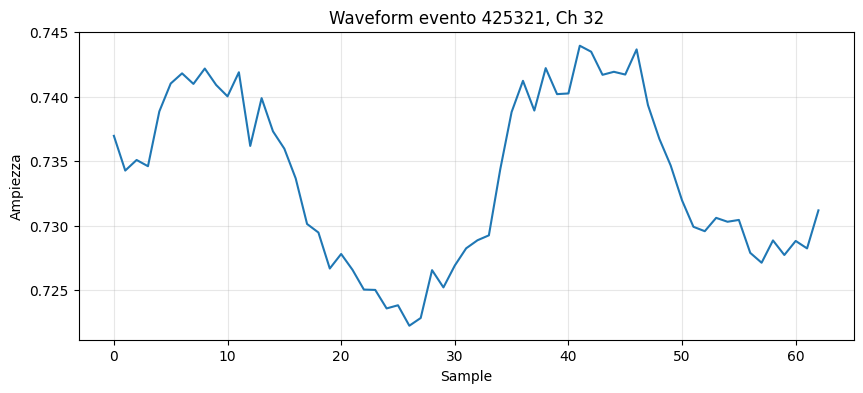

Min: 0.72225577
Max: 0.7439568
Media primi 10 sample (baseline): 0.738678


In [4]:


def analizza_waveform(wf, n_baseline=10):
    """
    n_baseline = quante sample iniziali usare per stimare la baseline
    """
    baseline = np.mean(wf[:n_baseline])
    wf_corr  = wf - baseline  # segnale centrato a zero (i punti a riposo oscillano intorno a 0)

    # --- Picco (minimo perché segnale negativo) ---
    idx_picco = np.argmin(wf_corr)
    ampiezza  = np.min(wf_corr)  # valore negativo (es. -100)

    # Se l'impulso è praticamente inesistente (solo rumore), restituisci NaN per evitare calcoli errati
    if ampiezza >= -1e-3: # adatta questa soglia al tuo rumore di fondo
        return {
            'baseline'  : baseline, 'integrale' : 0, 'ampiezza'  : ampiezza,
            'idx_picco' : idx_picco, 'rise_time' : np.nan, 'fwhm'      : np.nan,
        }

    # --- Integrale (carica) ---
    integrale = np.trapezoid(wf_corr)  # sarà negativo

    # --- Tempo di salita (10% → 90% del picco, andando verso il basso) ---
    soglia_10 = 0.10 * ampiezza  # es. -10
    soglia_90 = 0.90 * ampiezza  # es. -90
    
    try:
        # Fronte di discesa (dall'inizio al picco)
        fronte_salita = wf_corr[:idx_picco]
        
        # Cerchiamo partendo dal picco e tornando indietro (invertendo l'array con [::-1])
        # Vogliamo il primo punto che, tornando a zero, supera (diventa più vicino a zero, quindi >) la soglia
        idx_t90_retro = np.where(fronte_salita[::-1] >= soglia_90)[0][0]
        t90 = (idx_picco - 1) - idx_t90_retro
        
        idx_t10_retro = np.where(fronte_salita[::-1] >= soglia_10)[0][0]
        t10 = (idx_picco - 1) - idx_t10_retro
        
        rise_time = t90 - t10
        if rise_time <= 0: rise_time = np.nan
            
    except IndexError:
        rise_time = np.nan

    # --- FWHM ---
    soglia_half = 0.50 * ampiezza # es. -50
    try:
        # t_left: stessa logica del t90 (cerchiamo a ritroso dal picco)
        idx_left_retro = np.where(fronte_salita[::-1] >= soglia_half)[0][0]
        t_left = (idx_picco - 1) - idx_left_retro
        
        # t_right: guardiamo dal picco fino alla fine del segnale
        fronte_discesa = wf_corr[idx_picco:]
        # Cerchiamo in avanti il primo punto che risale sopra la metà ampiezza (diventa > di -50, es. -45)
        idx_right_avanti = np.where(fronte_discesa >= soglia_half)[0][0]
        t_right = idx_picco + idx_right_avanti
        
        fwhm = t_right - t_left
        if fwhm <= 0: fwhm = np.nan
    except IndexError:
        fwhm = np.nan

    return {
        'baseline'  : baseline,
        'integrale' : integrale,
        'ampiezza'  : ampiezza,
        'idx_picco' : idx_picco,
        'rise_time' : rise_time,
        'fwhm'      : fwhm,
    }

# Applica a tutto il DataFrame
features = df['Waveform'].apply(analizza_waveform)
df_feat  = pd.DataFrame(features.tolist())
df       = pd.concat([df.reset_index(drop=True), df_feat], axis=1)

print(df[['event_idx', 'Channel', 'Detector', 'integrale', 'ampiezza', 'rise_time', 'fwhm']].head(10))

plt.figure(figsize=(10,4))
plt.plot(df['Waveform'].iloc[7])  # uso iloc[1] che ha ampiezza più grande
plt.grid(True, alpha=0.3)
plt.ylabel("Ampiezza")
plt.xlabel("Sample")
plt.title(f"Waveform evento {df['event_idx'].iloc[7]}, Ch {int(df['Channel'].iloc[7])}")
plt.show()

print("Min:", df['Waveform'].iloc[7].min())
print("Max:", df['Waveform'].iloc[7].max())
print("Media primi 10 sample (baseline):", df['Waveform'].iloc[7][:10].mean())

In [5]:
#keeping only good waveform
df_good = df.copy() # per sicurezza, così non modifico df originale
df_good = df[(df['rise_time'] < 10) & (df['integrale'] >-20)]
print(f"Eventi con rise time < 10 sample e integrale < -20: {len(df_good)}")
print(df_good[['event_idx', 'Channel', 'Detector', 'integrale', 'rise_time']].head())

Eventi con rise time < 10 sample e integrale < -20: 222455
   event_idx  Channel  Detector  integrale  rise_time
0      10199       32       2.0   0.007746        4.0
2     120430       32       2.0   0.036513        3.0
3     405399       32       2.0   0.020309        3.0
4     425055       32       2.0  -0.291382        4.0
5     425319       32       2.0  -0.019202        9.0


In [6]:
from scipy.optimize import curve_fit

def sigmoid_neg(x, x0, k):
    """Sigmoide normalizzata tra 0 e 1"""
    return 1 / (1 + np.exp(-k * (x - x0)))

def fit_sigmoid_2p(wf, idx_picco):
    start = max(0, idx_picco - 8)
    x_data = np.arange(start, idx_picco + 1)
    y_data = wf[start:idx_picco + 1]

    # Normalizza tra 0 e 1 (gestisce il segno negativo automaticamente)
    B = np.mean(wf[:10])           # baseline
    A = wf[idx_picco] - B          # ampiezza (negativa)
    y_norm = (y_data - B) / A      # ora va da ~0 a ~1

    p0 = [(start + idx_picco) / 2, 0.5]
    bounds = ([start, 0.01], [idx_picco, 5])

    try:
        popt, _ = curve_fit(sigmoid_neg, x_data, y_norm, p0=p0, bounds=bounds)
        x0, k = popt

        # Tempo al 30%: inversa della sigmoide normalizzata
        # 0.30 = 1 / (1 + exp(-k*(t - x0)))  →  t = x0 - ln(1/0.3 - 1) / k
        t_cfd = x0 - np.log(1 / 0.30 - 1) / k
        return x0, k, t_cfd

    except RuntimeError:
        return None

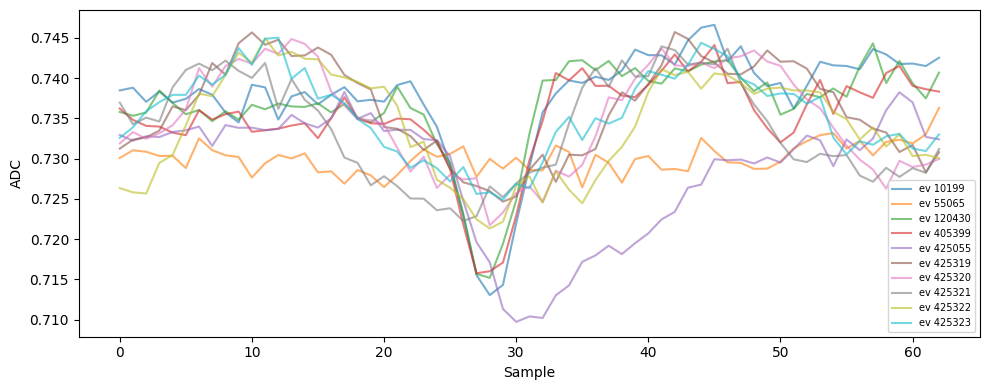

In [7]:
#plot some waveform of channel (9,5) of detector 2
fig, ax = plt.subplots(figsize=(10,4))
plot_counter = 0
MAX_PLOT = 10 # quante waveform vuoi vedere

for idx, row in df[(df['xCoord'] == 9) & (df['yCoord'] == 5) & (df['Detector'] == 2)].iterrows():
    if plot_counter >= MAX_PLOT:
        break
    wf = np.array(row['Waveform'])
    ax.plot(wf, alpha=0.6, label=f"ev {row['event_idx']}")
    plot_counter += 1

ax.set_xlabel("Sample")
ax.set_ylabel("ADC")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()
    
    


In [8]:
# print numero di eventi canale (9,5) detector 2
n_canale_9_5_det2 = len(df[(df['xCoord'] == 9) & (df['yCoord'] == 5) & (df['Detector'] == 2)])
print(f"Numero di eventi con canale (9,5) del detector 2: {n_canale_9_5_det2}")

Numero di eventi con canale (9,5) del detector 2: 398630


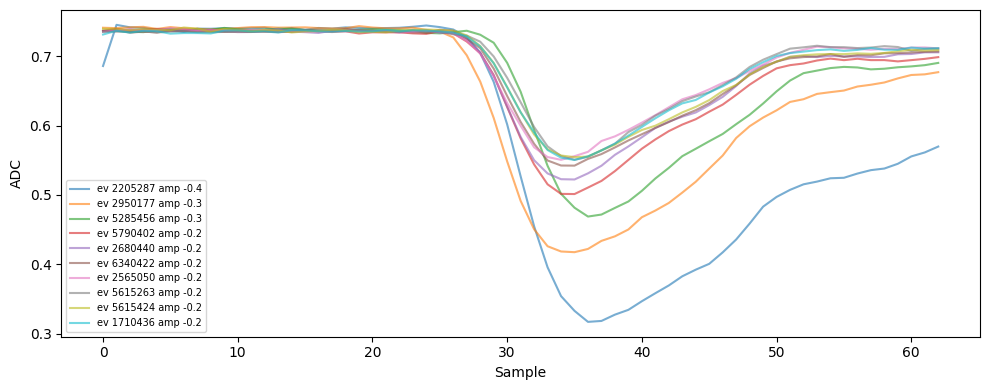

In [9]:
#plot waveforms with higher amplitude 
fig, ax = plt.subplots(figsize=(10,4))
plot_counter = 0
for idx, row in df_good.sort_values(by='ampiezza').iterrows():
    if plot_counter >= MAX_PLOT:
        break
    wf = np.array(row['Waveform'])
    ax.plot(wf, alpha=0.6, label=f"ev {row['event_idx']} amp {row['ampiezza']:.1f}")
    plot_counter += 1   
ax.set_xlabel("Sample")
ax.set_ylabel("ADC")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

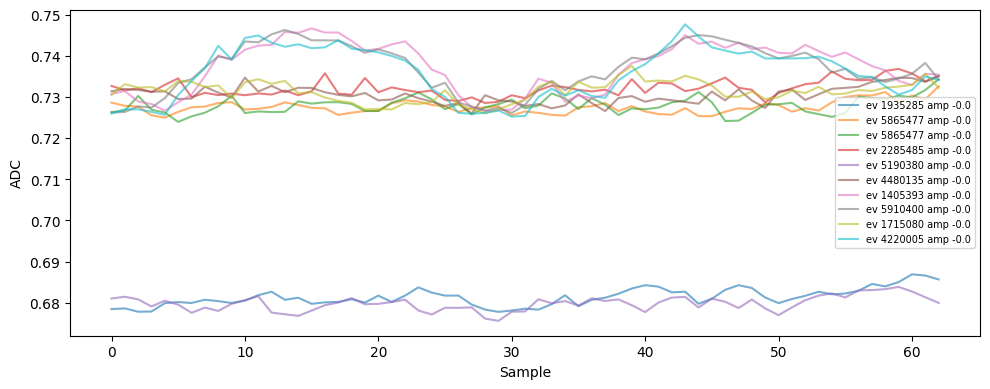

In [10]:
#plot waveform with lower amplitude
fig, ax = plt.subplots(figsize=(10,4))
plot_counter = 0
for idx, row in df_good.sort_values(by='ampiezza', ascending=False).iterrows():
    if plot_counter >= MAX_PLOT:
        break
    wf = np.array(row['Waveform'])
    ax.plot(wf, alpha=0.6, label=f"ev {row['event_idx']} amp {row['ampiezza']:.1f}")
    plot_counter += 1
ax.set_xlabel("Sample")
ax.set_ylabel("ADC")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

In [16]:
#count waveforms with low amplitude > -0.02
n_low_amp = len(df_good[df_good['ampiezza'] > -0.02])
print(f"Numero di waveforms con ampiezza > -0.02: {n_low_amp}")
n_high_amp = len(df_good[df_good['ampiezza'] <= -0.02])
print(f"Numero di waveforms con ampiezza <= -0.02: {n_high_amp}")

Numero di waveforms con ampiezza > -0.02: 222051
Numero di waveforms con ampiezza <= -0.02: 404


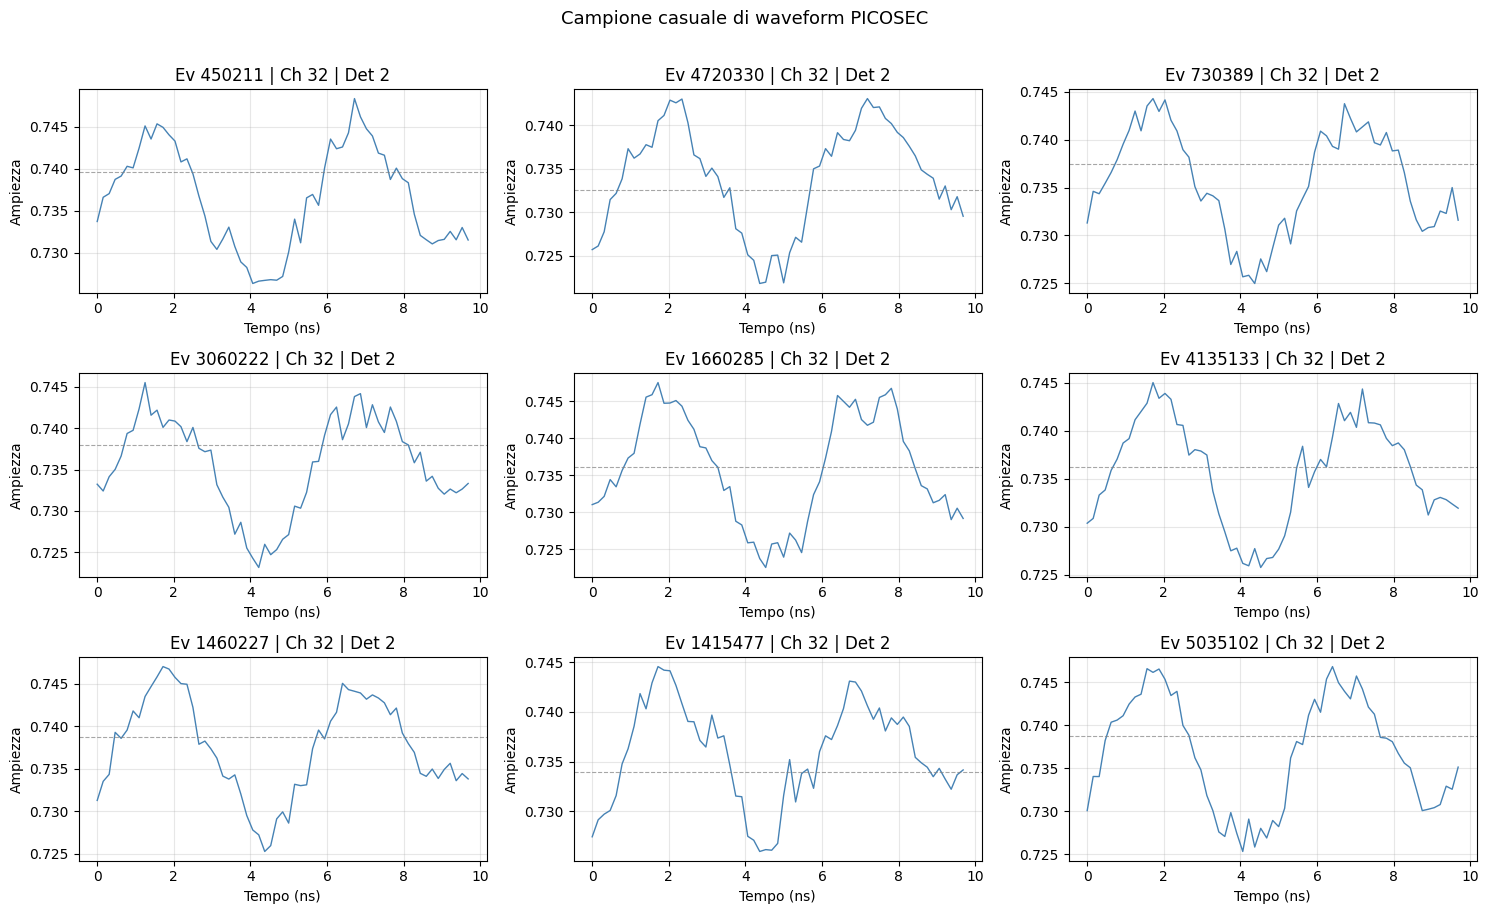

In [17]:
#PLOT SOME RANDOM WAVEFORM WIHT AMPLITUDE ABOVE -0.02
df_low_amp = df_good[df_good['ampiezza'] > -0.02]
fig, axes = plt.subplots(3, 3, figsize=(15, 9))

# Campiona 9 righe casuali
sample = df_low_amp.sample(9, random_state=42).reset_index(drop=True)

for idx, ax in enumerate(axes.flat):
    riga = sample.iloc[idx]
    wf   = riga['Waveform']
    t_ns = np.arange(len(wf)) * (1/6.4)  # converti sample → ns
    
    ax.plot(t_ns, wf, color='steelblue', lw=1)
    ax.axhline(float(riga['baseline']), color='gray', linestyle='--', lw=0.8, alpha=0.7)
    ax.set_xlabel("Tempo (ns)")
    ax.set_ylabel("Ampiezza")
    ax.set_title(f"Ev {int(riga['event_idx'])} | Ch {int(riga['Channel'])} | Det {int(riga['Detector'])}")
    ax.grid(True, alpha=0.3)

plt.suptitle("Campione casuale di waveform PICOSEC", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()